<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Conectar Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cargar el dataset
ruta_archivo = '/content/gdrive/MyDrive/SIS420IA/Mall_Customers.csv'
df = pd.read_csv(ruta_archivo)

Mounted at /content/gdrive


--- INICIANDO EJERCICIO 2D ---
K=2 -> Silueta: 0.3956
K=3 -> Silueta: 0.4676
K=4 -> Silueta: 0.4938
K=5 -> Silueta: 0.5539
K=6 -> Silueta: 0.5128
K=7 -> Silueta: 0.5017
K=8 -> Silueta: 0.4963
K=9 -> Silueta: 0.4559
K=10 -> Silueta: 0.4426


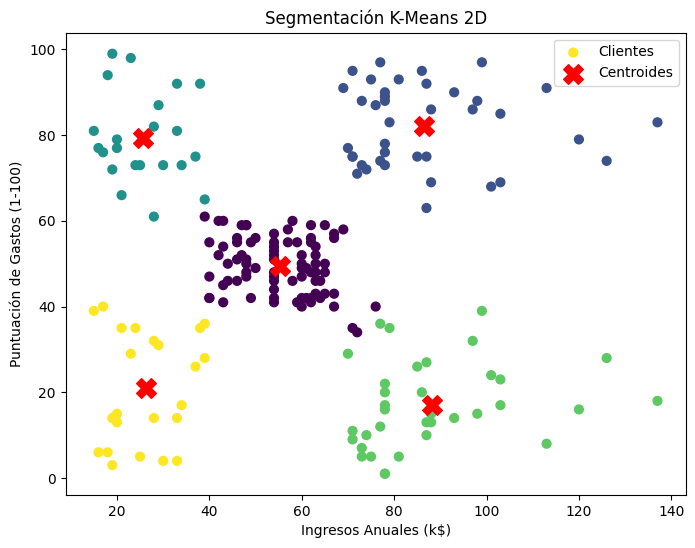

In [3]:
print("--- INICIANDO EJERCICIO 2D ---")
# 1. Extraer X en 2D
X_2d = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# 2. Encontrar el K óptimo con el coeficiente de silueta
silhouette_scores_2d = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_2d)
    score = silhouette_score(X_2d, kmeans.labels_)
    silhouette_scores_2d.append(score)
    print(f"K={k} -> Silueta: {score:.4f}")


mejor_k_2d = 5
kmeans_2d = KMeans(n_clusters=mejor_k_2d, random_state=42, n_init='auto')
y_predict_2d = kmeans_2d.fit_predict(X_2d)
centroides_2d = kmeans_2d.cluster_centers_

# 4. Graficar en 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_predict_2d, cmap='viridis', s=40, label='Clientes')
plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Segmentación K-Means 2D')
plt.xlabel('Ingresos Anuales (k$)')
plt.ylabel('Puntuación de Gastos (1-100)')
plt.legend()
plt.show()

--- INICIANDO EJERCICIO 3D ---
K=2 -> Silueta: 0.3320
K=3 -> Silueta: 0.3356
K=4 -> Silueta: 0.4055
K=5 -> Silueta: 0.3576
K=6 -> Silueta: 0.4156
K=7 -> Silueta: 0.4420
K=8 -> Silueta: 0.4328
K=9 -> Silueta: 0.4093
K=10 -> Silueta: 0.3968


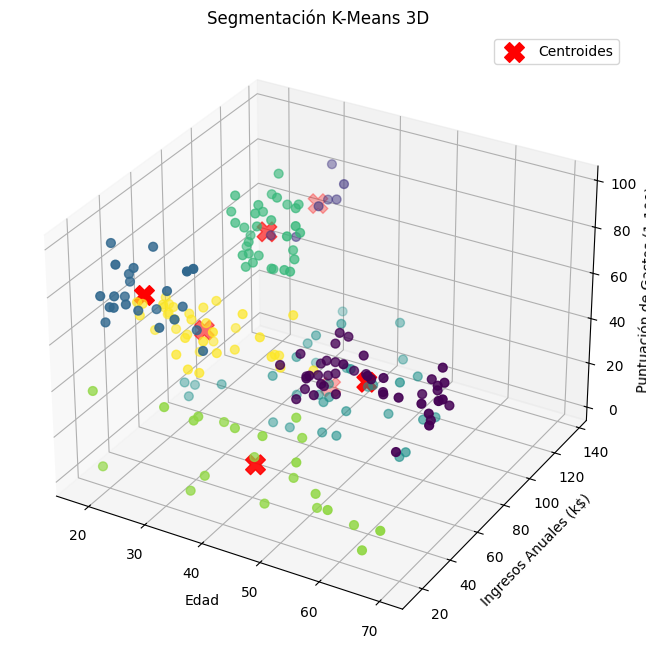

In [5]:
print("--- INICIANDO EJERCICIO 3D ---")
# 1. Extraer X en 3D
X_3d = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

# 2. Encontrar el K óptimo con el coeficiente de silueta
silhouette_scores_3d = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_3d)
    score = silhouette_score(X_3d, kmeans.labels_)
    silhouette_scores_3d.append(score)
    print(f"K={k} -> Silueta: {score:.4f}")

# 3. Entrenar el modelo final
# Nota: Ajusta el número según lo que te imprima el ciclo anterior
mejor_k_3d = 7
kmeans_3d = KMeans(n_clusters=mejor_k_3d, random_state=42, n_init='auto')
y_predict_3d = kmeans_3d.fit_predict(X_3d)
centroides_3d = kmeans_3d.cluster_centers_

# 4. Graficar en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # Esto activa el modo 3D

# Graficamos los clientes
# X_3d[:, 0] = Edad, X_3d[:, 1] = Ingresos, X_3d[:, 2] = Puntuación
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y_predict_3d, cmap='viridis', s=40)

# Graficamos los centroides en rojo
ax.scatter(centroides_3d[:, 0], centroides_3d[:, 1], centroides_3d[:, 2],
           c='red', marker='X', s=200, label='Centroides')

ax.set_title('Segmentación K-Means 3D')
ax.set_xlabel('Edad')
ax.set_ylabel('Ingresos Anuales (k$)')
ax.set_zlabel('Puntuación de Gastos (1-100)')
plt.legend()
plt.show()